# Part I: Exploratory Data Analysis

### By: Christopher O'Hara, PhD, EngD

**Datasets:**
- Kaggle nuclear power plant locations/exposure: https://www.kaggle.com/datasets/liananapalkova/nuclear-power-plants
- IAEA nuclear electricity statistics 2022: https://www.kaggle.com/datasets/kanchana1990/nuclear-share-of-electricity-generation

**Why both / why merge?** The plant dataset provides infrastructure and fleet size by country/region (sites, reactors), while the IAEA share dataset provides how much electricity is actually sourced from nuclear. Merging on country lets us relate asset counts to delivered energy contribution, revealing where architecture and policy diverge.



## Introduction

**Why this topic:** As a systems architect, I am interested in system-level impacts of technology on society. These datasets allow for insight into sociotechnical debt. Fleet composition, geographic deployment, and reliance levels expose how different grid architectures and policy choices shape resilience and capacity planning.

Guiding questions:
- How are plants and reactors distributed by region and country?
- How do nuclear generation shares relate to plant counts and reactors?
- Do countries with more reactors show higher nuclear share, or is capacity a better predictor?

## Preliminary Wrangling
Basic harmonization of country keys and merge to align fleet data with nuclear share.

### What is the structure of your dataset?
- Plants: 276 rows, 61 columns (site/location plus multiple exposure metrics) across 7 regions.
- IAEA share: 32 rows, 5 columns (net capacity, operated reactors, nuclear share %) for 2022.
- Merged: 32 country rows with aggregated plant counts/reactors and regional tag.

### What is/are the main feature(s) of interest in your dataset?

Main focus: `nuclear_share_pct` (reliance on nuclear electricity) and how it varies by reactor fleet size (`operated_reactors`) and region.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?
Supporting features: net capacity (`net_capacity_mw`), plant count (`num_plants`), summed reactors (`reactors_reported`), and `region` to contextualize fleets and reliance.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

data_plants = pd.read_csv('data_raw/energy-pop-exposure-nuclear-plants-locations_plants.csv')
data_share = pd.read_csv('data_raw/Nuclear_Electricity_Statistics_2022.csv')

# Basic harmonization
plants = data_plants.copy()
share = data_share.rename(columns={
    'Total Net Electrical Capacity [MW]': 'net_capacity_mw',
    'Number of Operated Reactors': 'operated_reactors',
    'Nuclear Electricity Supplied [GW.h]': 'nuclear_gwh',
    'Nuclear Share [%]': 'nuclear_share_pct'
})
share['Country_clean'] = share['Country'].str.upper().str.strip()

plants['Country_clean'] = plants['Country'].str.upper().str.strip()
country_summary = (plants.groupby('Country_clean')
                   .agg(num_plants=('Plant','nunique'),
                        reactors_reported=('NumReactor','sum'),
                        region=('Region','first'),
                        mean_p90_1200=('p90_1200','mean'))
                   .reset_index())
merged = share.merge(country_summary, on='Country_clean', how='left')
print(f"Plants rows: {plants.shape}, Share rows: {share.shape}, Merged rows: {merged.shape}")

Plants rows: (276, 62), Share rows: (32, 6), Merged rows: (32, 10)


## Data glimpses

In [2]:
plants.head()

,FID,Region,Country,Plant,NumReactor,Latitude,Longitude,p90_1200,p00_1200,p10_1200,...,p90_300,p00_300,p10_300,p90u_300,p00u_300,p10u_300,p90r_300,p00r_300,p10r_300,Country_clean
0,0,Europe - Western,SWEDEN,AGESTA,1,59.206022,18.082872,187382000,188684000,188250000,...,5013240.0,5227700.0,5471110.0,3426880.0,3596030.0,3764920.0,1586350.0,1631670.0,1706190,SWEDEN
1,1,Europe - Western,SPAIN,ALMARAZ,2,39.808100,-5.696940,136675000,147718000,163429000,...,17756500.0,18187800.0,20185200.0,10986000.0,11415400.0,12689800.0,6770480.0,6772380.0,7495340,SPAIN
2,2,America - Latin,BRAZIL,ANGRA,3,-23.007857,-44.458098,99195200,113894000,127898000,...,39546400.0,44701700.0,50210600.0,32788500.0,37064600.0,41648300.0,6757940.0,7637110.0,8562300,BRAZIL
3,3,America - Northern,UNITED STATES OF AMERICA,ARKANSAS ONE,2,35.310320,-93.231289,117830000,132729000,146482000,...,5603180.0,6226360.0,6866840.0,3779400.0,4198920.0,4633770.0,1823770.0,2027450.0,2233070,UNITED STATES OF AMERICA
4,4,Europe - Western,SPAIN,ASCO,2,41.200000,0.566670,271854000,287134000,308922000,...,14398500.0,15095600.0,16830700.0,11215400.0,11773600.0,13151300.0,3183180.0,3322050.0,3679470,SPAIN


In [3]:
share.head()

,Country,net_capacity_mw,operated_reactors,nuclear_gwh,nuclear_share_pct,Country_clean
0,ARGENTINA,1641,3,7469.52,5.4,ARGENTINA
1,ARMENIA,416,1,2630.85,31.0,ARMENIA
2,BELARUS,1110,1,4411.35,11.9,BELARUS
3,BELGIUM,5942,7,41744.41,46.4,BELGIUM
4,BRAZIL,1884,2,13744.82,2.5,BRAZIL


## Univariate exploration
- Distribution of nuclear share
- Count of plants by region

**Question:** How is nuclear share distributed across countries?

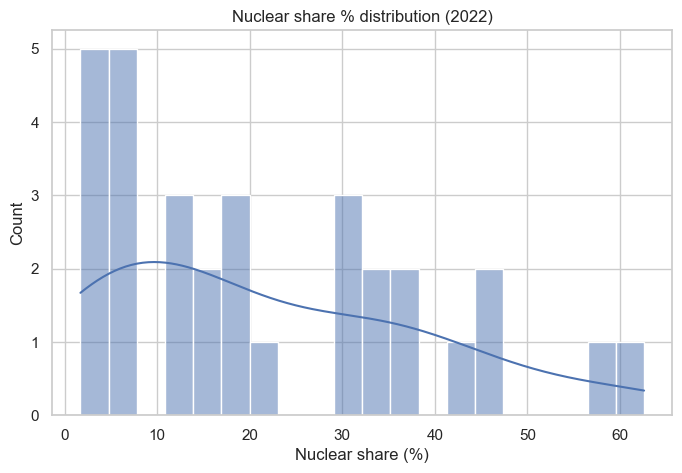

In [ ]:
sns.histplot(merged['nuclear_share_pct'].dropna(), bins=20, kde=True); plt.title('Nuclear share % distribution (2022)'); plt.xlabel('Nuclear share (%)'); plt.show()

**Answer:** Nuclear share ranges from ~2% to ~63% with a right-skewed distribution; median ~18% and a small group of high-reliance countries at the upper end.

**Question:** Which regions host the most nuclear plant sites?

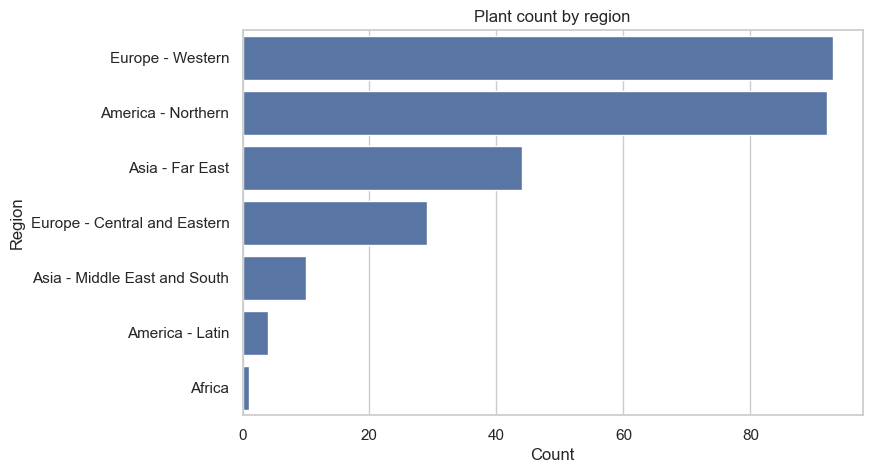

In [ ]:
sns.countplot(data=plants, y='Region', order=plants['Region'].value_counts().index); plt.title('Plant count by region'); plt.xlabel('Count'); plt.ylabel('Region'); plt.show()

**Answer:** Western Europe and Northern America dominate plant counts, followed by Asia (Far East); Africa and Latin America have only a handful of sites.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points- Did you need to perform any transformations?
`nuclear_share_pct` is right-skewed (median ~18%, tail up to ~63%). High-reliance countries form a long tail; no transform applied, but a log x-axis could emphasize low-share spread.

### Of the features you investigated, were there any unusual distributions- Did you perform any operations on the data to tidy, adjust, or change the form of the data- If so, why did you do this?
Region counts are imbalanced (Europe/Northern America dominate). Reactor counts and capacity span wide ranges, so reactor counts were binned to avoid sparsity. Countries were uppercased/trimmed to merge cleanly.

## Bivariate exploration
- Nuclear share vs operated reactors
- Nuclear share by region

**Question:** Does running more reactors imply higher nuclear electricity share?

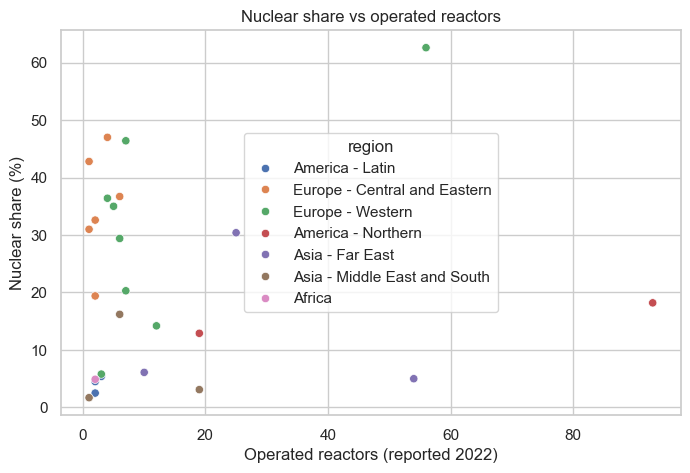

In [6]:
sns.scatterplot(data=merged, x='operated_reactors', y='nuclear_share_pct', hue='region'); plt.title('Nuclear share vs operated reactors'); plt.xlabel('Operated reactors (reported 2022)'); plt.ylabel('Nuclear share (%)'); plt.show()

**Answer:** Not strongly: the correlation is near zero (~0.07). Some countries reach high share with modest reactor counts, while others operate many reactors with only moderate share.

**Question:** How does nuclear share vary by region?

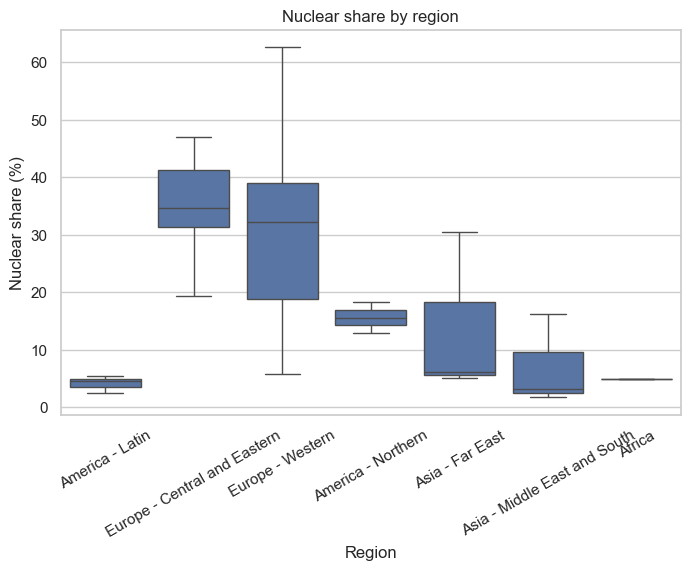

In [7]:
sns.boxplot(data=merged, x='region', y='nuclear_share_pct'); plt.xticks(rotation=30); plt.title('Nuclear share by region'); plt.xlabel('Region'); plt.ylabel('Nuclear share (%)'); plt.show()

**Answer:** Median share is highest in Europe (Central/Eastern and Western), moderate in Northern America, and lower in Asia, Latin America, and Africa.

**Question:** How does nuclear share relate to net capacity when encoding reactor count and region?

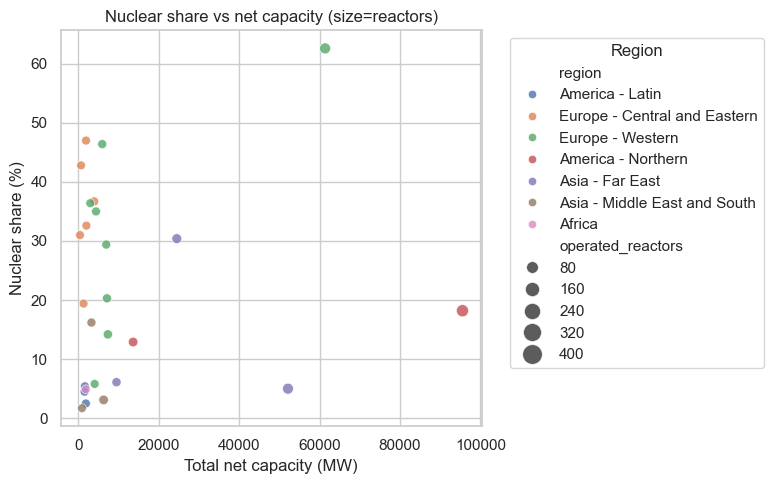

In [8]:
sns.scatterplot(data=merged, x='net_capacity_mw', y='nuclear_share_pct', hue='region', size='operated_reactors', sizes=(40,200), alpha=0.8)
plt.title('Nuclear share vs net capacity (size=reactors)')
plt.xlabel('Total net capacity (MW)')
plt.ylabel('Nuclear share (%)')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Region')
plt.tight_layout()
plt.show()

**Answer:** Higher net capacity loosely aligns with higher nuclear share only in some regions; Europe again stands out with above-average share at moderate capacities and reactor counts, while other regions show wide share variance even at similar capacities.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?
Nuclear share varies more by region than by sheer reactor count: European regions maintain higher shares across bins, while other regions only exceed ~15% when fleets reach 6-10 reactors.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?
Plant sites are heavily concentrated in Western Europe and Northern America; capacity totals mirror this concentration, highlighting uneven infrastructure distribution.

## Multivariate exploration
- Facet nuclear share by region and plant count buckets-
- Heatmap of reactor counts by region vs share bucket-

**Question:** How does reactor fleet size relate to nuclear share within regions?

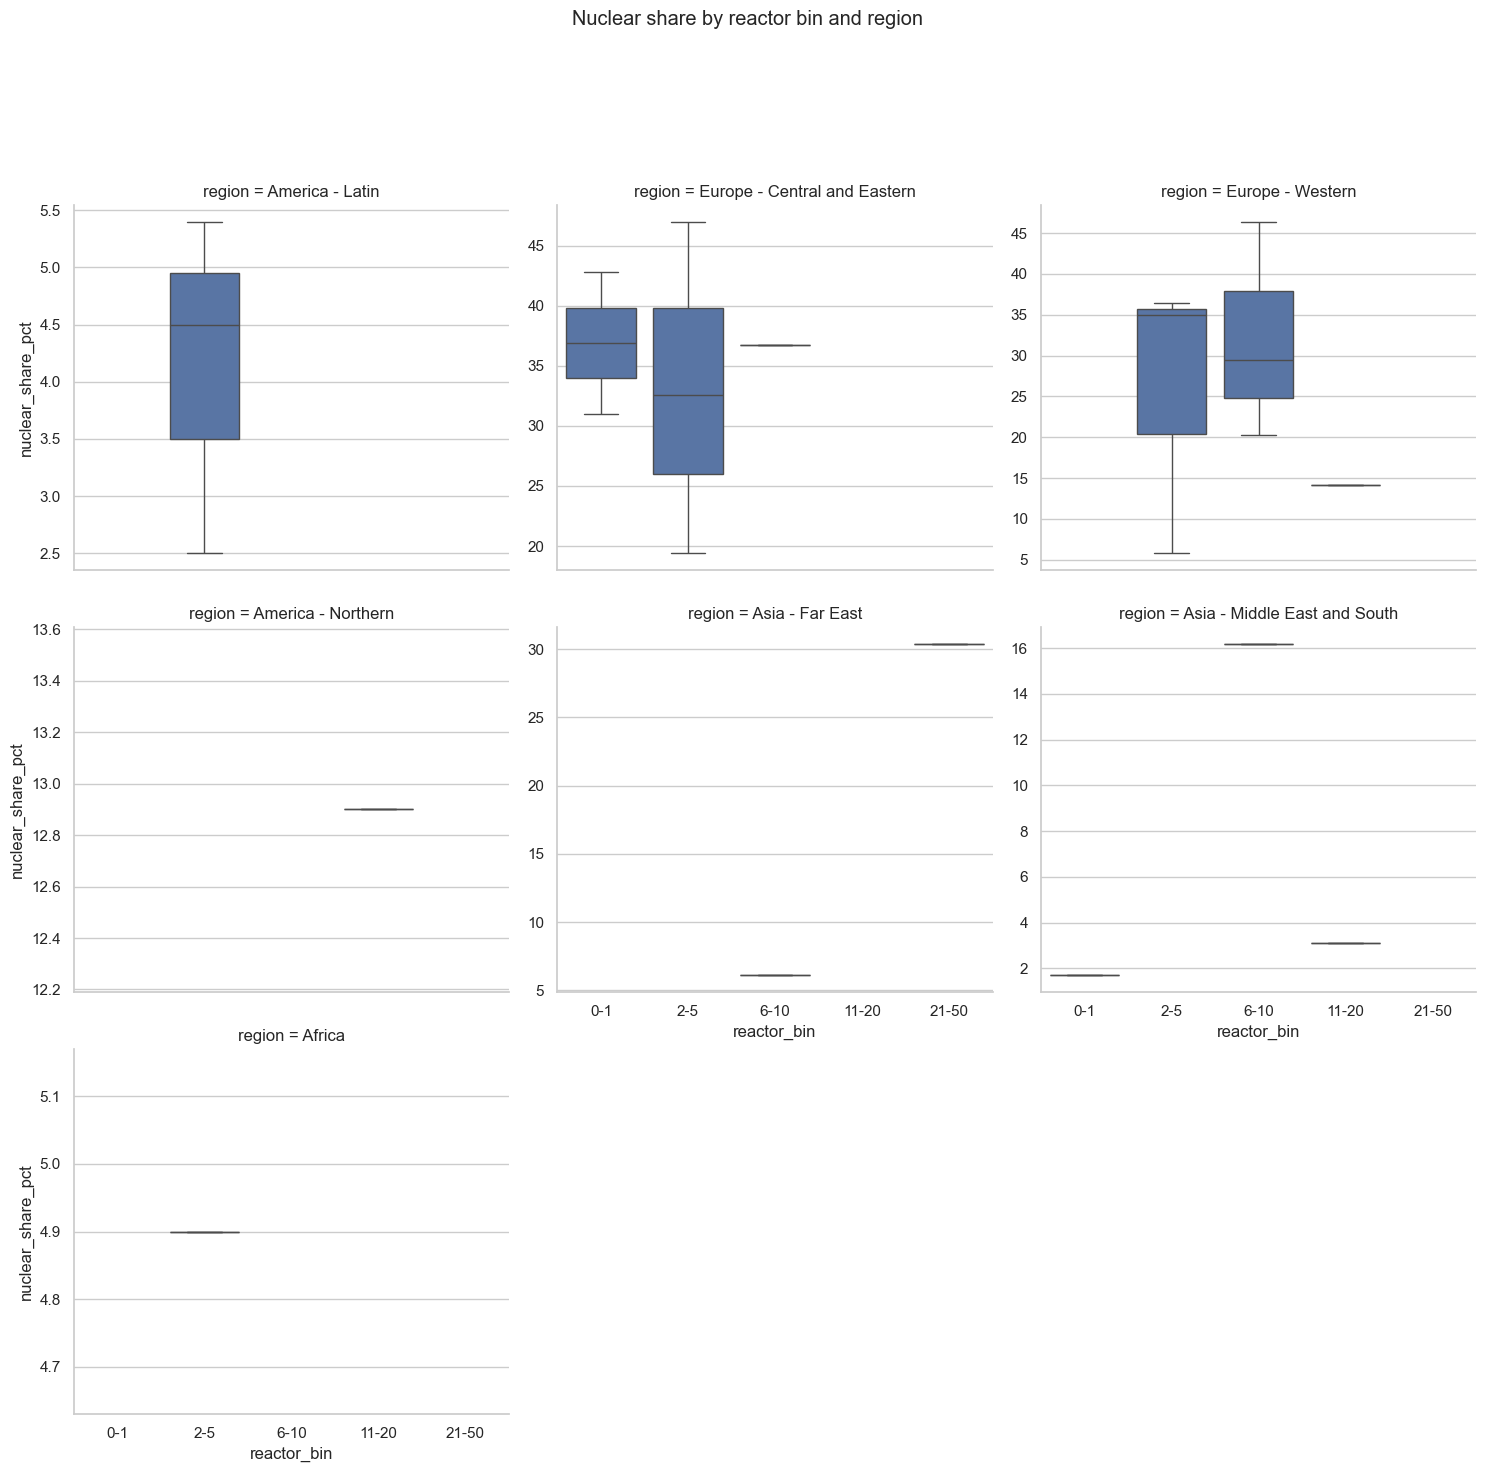

In [9]:
merged['reactor_bin'] = pd.cut(merged['operated_reactors'], bins=[-0.5,1,5,10,20,50], labels=['0-1','2-5','6-10','11-20','21-50'])
sns.catplot(data=merged, x='reactor_bin', y='nuclear_share_pct', col='region', kind='box', col_wrap=3, sharey=False)
plt.subplots_adjust(top=0.85)
plt.suptitle('Nuclear share by reactor bin and region')
plt.show()

**Answer:** Europe maintains comparatively high share even in smaller fleet bins, while other regions only exceed ~15% when fleets reach 6-10 reactors; shares are lowest for regions with 0-1 reactors.

**Question:** Which region-fleet combinations show the highest average nuclear share-

C:\Users\Ohara\AppData\Local\Temp\ipykernel_35516\1440638058.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = merged.pivot_table(index='region', columns='reactor_bin', values='nuclear_share_pct', aggfunc='mean')


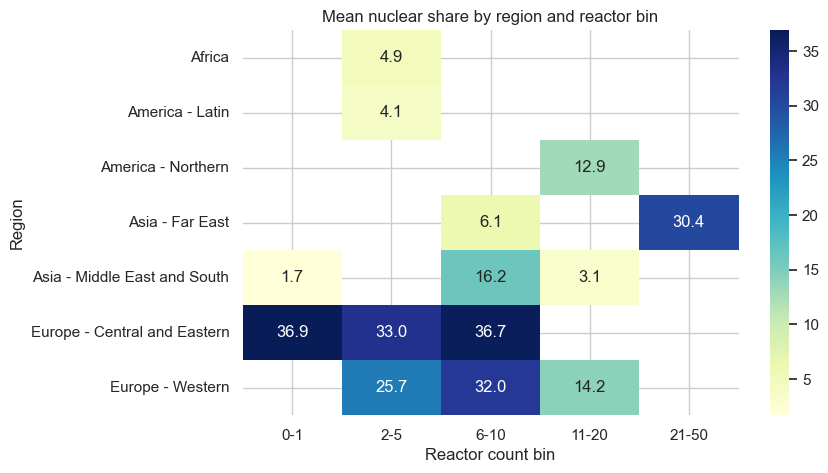

In [10]:
pivot = merged.pivot_table(index='region', columns='reactor_bin', values='nuclear_share_pct', aggfunc='mean')
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt='.1f')
plt.title('Mean nuclear share by region and reactor bin')
plt.xlabel('Reactor count bin')
plt.ylabel('Region')
plt.show()

**Answer:** Central/Eastern Europe shows ~33-37% share across small and mid-sized fleets; Western Europe ~26-32% for 2-10 reactors; Asia Far East rises to ~30% only in the largest bin (21-50).

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest)?
Combining region with fleet size clarified reliance: region acted as a strong modifier, strengthening the explanation of why similar fleet sizes yield different nuclear shares.

### Were there any interesting or surprising interactions between features?
Yes: Europe attains high nuclear share at moderate capacity and reactor counts, whereas other regions with similar capacities show much lower shares; this points to policy or mix effects rather than scale alone.

## Conclusion
Nuclear reliance varies widely: a few European countries sustain 30-60% shares even with modest fleets, while most regions with small fleets rely on nuclear for under 15% of generation. Fleet size alone does not explain nuclear share; regional energy mix and policy choices likely drive the outliers. Data coverage is limited to 2022 shares and 32 countries, so trends over time and missing reactor counts for some countries should be handled with care.

## Summary / Reflection
Exploration shows reliance is shaped more by regional policy and mix than raw fleet size. Future work could add time-series shares and capacity factors to understand trends rather than a single-year snapshot.